In [1]:
#monuting drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#importing train_data set

import pandas as pd

train_data= pd.read_csv("/content/drive/MyDrive/Data science project/Hotel-A-train.csv")



##Missing values

In [3]:
print(train_data.isnull().sum())

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64


##Duplicates

In [4]:
#Checking for duplicating entries after dropping ID column

# Temporarily drop 'Reservation-id' to check for duplicate entries
train_data_no_id = train_data.drop(columns=['Reservation-id'])

duplicate_rows_count = train_data_no_id.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows_count}")

Number of duplicate rows: 0


##Data type errors

In [5]:
train_data.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,object
Expected_checkout,object


In [6]:
#Convert Date columns to Datetime objects
date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']
for col in date_cols:
    train_data[col] = pd.to_datetime(train_data[col], errors='coerce')


train_data.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


##Data integrity issues

In [7]:
train_data["Reservation-id"].duplicated().sum()


np.int64(4)

In [8]:
duplicated_ids = train_data['Reservation-id'].duplicated(keep=False)
duplicated_reservation_rows = train_data[duplicated_ids]

display(duplicated_reservation_rows)

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
2719,95504255,M,68,Asian American,College,50K -- 100K,North,Airport Hotels,2015-10-29,2015-10-30,...,BB,No,No,No Deposit,Direct,Yes,Check-Out,Yes,5,231
6748,55371044,F,21,caucasian,High-School,<25K,South,Airport Hotels,2015-10-12,2015-10-16,...,BB,No,No,Refundable,Online,Yes,Check-Out,Yes,10,127
6779,55371044,F,20,African American,College,50K -- 100K,West,Airport Hotels,2016-06-30,2016-07-02,...,HB,No,No,No Deposit,Direct,Yes,Check-Out,Yes,25,166
7456,95504255,M,36,African American,High-School,<25K,North,Resort,2016-05-12,2016-05-14,...,BB,No,No,No Deposit,Direct,Yes,Check-Out,Yes,10,173
15701,91130744,M,49,Asian American,High-School,50K -- 100K,North,Airport Hotels,2015-07-31,2015-08-01,...,FB,Yes,No,No Deposit,Online,No,No-Show,Yes,5,197
17160,91130744,M,19,Latino,Mid-School,50K -- 100K,South,Airport Hotels,2015-09-28,2015-09-29,...,HB,Yes,No,No Deposit,Agent,Yes,Check-Out,Yes,40,113
17661,76641511,F,66,Asian American,College,<25K,West,Resort,2015-10-19,2015-10-22,...,BB,No,No,No Deposit,Direct,Yes,No-Show,Yes,20,170
20197,76641511,F,27,caucasian,College,<25K,South,Resort,2016-01-20,2016-01-21,...,HB,No,No,Refundable,Online,Yes,No-Show,No,0,236


In [9]:
#4 of the records have same reservation id but with different info.

In [10]:
# Remove all instances of corrupted IDs
train_data = train_data.drop_duplicates(subset=['Reservation-id'], keep=False)

print(train_data.shape)

(27491, 24)


##Inconsistent Formatting

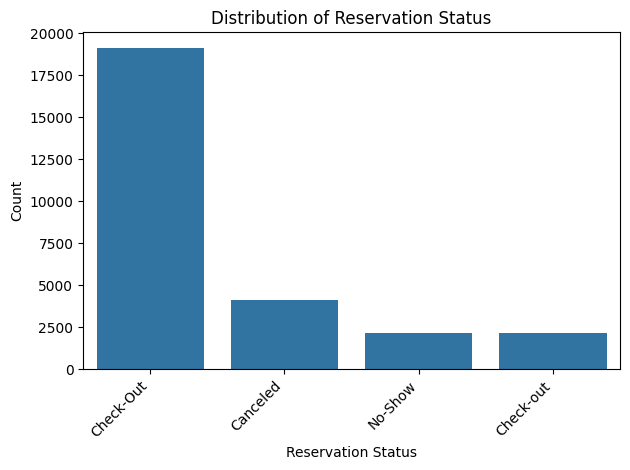

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=train_data, x='Reservation_Status')
plt.title('Distribution of Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Standardize the 'Reservation_Status' column to be Title Case
train_data['Reservation_Status'] = train_data['Reservation_Status'].str.title()

# Verify the fix
print(train_data['Reservation_Status'].value_counts())

Reservation_Status
Check-Out    21235
Canceled      4134
No-Show       2122
Name: count, dtype: int64


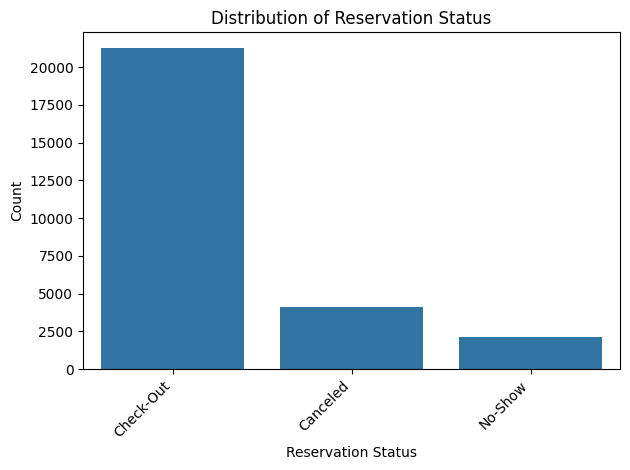

In [13]:
sns.countplot(data=train_data, x='Reservation_Status')
plt.title('Distribution of Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Logic errors

In [14]:
# Identify "Time-Travel" Issues
# Issue A: Checking in before you even booked the room
issue_a = train_data[train_data['Expected_checkin'] < train_data['Booking_date']]

# Issue B: Checking out before you checked in
issue_b = train_data[train_data['Expected_checkin'] > train_data['Expected_checkout']]

# 3. Combine and Report
time_anomalies = pd.concat([issue_a, issue_b]).drop_duplicates()

print(f"Total rows with booking/check-in overlap: {len(issue_a)}")
print(f"Total rows with check-in/checkout overlap: {len(issue_b)}")
print(f"Total unique anomaly rows found: {len(time_anomalies)}")

Total rows with booking/check-in overlap: 505
Total rows with check-in/checkout overlap: 0
Total unique anomaly rows found: 505


In [15]:
train_data = train_data.drop(time_anomalies.index, errors='ignore')
print(train_data.shape)
train_data.head()

(26986, 24)


,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,2015-07-01,2015-07-02,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,2015-07-01,2015-07-02,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,2015-07-02,2015-07-06,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,2015-07-02,2015-07-03,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,2015-07-03,2015-07-04,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


In [16]:
# 1. Check for 'Adult-less' check-ins (Children/Babies but 0 Adults)
adultless_bookings = train_data[(train_data['Adults'] == 0) & ((train_data['Children'] > 0) | (train_data['Babies'] > 0))]
print(f"Number of bookings with children/babies but 0 adults: {len(adultless_bookings)}")

# 2. Check for 'Ghost' bookings (Total Guests = 0)
# We calculate a temporary total to check before we drop the originals
temp_total = train_data['Adults'] + train_data['Children'] + train_data['Babies']
ghost_bookings = train_data[temp_total == 0]
print(f"Number of bookings with 0 total guests: {len(ghost_bookings)}")

Number of bookings with children/babies but 0 adults: 0
Number of bookings with 0 total guests: 0


##Feature Engineering

In [17]:
# Calculate Lead Time (Days between booking and arrival)
train_data['Lead_Time'] = (train_data['Expected_checkin'] - train_data['Booking_date']).dt.days

# Calculate Total Nights (Duration of stay)
train_data['Total Nights'] = (train_data['Expected_checkout'] - train_data['Expected_checkin']).dt.days

train_data[['Lead_Time', 'Total Nights']]

,Lead_Time,Total Nights
0,41,1
1,36,1
2,3,4
3,12,1
4,13,1
...,...,...
27494,37,1
27495,127,1
27496,9,1
27497,98,1


In [18]:

# Extract Month (1-12) and Day of Week (0=Monday, 6=Sunday)
train_data['Checkin_Month'] = train_data['Expected_checkin'].dt.month
train_data['Checkin_Day_of_Week'] = train_data['Expected_checkin'].dt.dayofweek

# Optional: Is it a weekend? (1 if Saturday/Sunday, else 0)
train_data['Is_Weekend'] = train_data['Checkin_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

train_data[['Checkin_Month', 'Checkin_Day_of_Week','Is_Weekend']]

,Checkin_Month,Checkin_Day_of_Week,Is_Weekend
0,7,2,0
1,7,2,0
2,7,3,0
3,7,3,0
4,7,4,0
...,...,...,...
27494,8,2,0
27495,8,2,0
27496,9,3,0
27497,8,2,0


In [19]:
#Total guests

train_data['Total_Guests'] = train_data['Adults'] + train_data['Children'] + train_data['Babies']

train_data[['Total_Guests']]

,Total_Guests
0,4
1,6
2,6
3,7
4,2
...,...
27494,4
27495,3
27496,4
27497,5


In [20]:
#Remove total guests more than 5 (Business rule: one room can accommodate up to 5 people including children (Except babies))

# Count how many rows have more than 5 guests (excluding babies)
more_than_5_count = (train_data['Adults'] + train_data['Children'] > 5).sum()

print(f"Number of bookings with more than 5 guests (excluding babies): {more_than_5_count}")


# Drop rows where Adults + Children > 5 by keeping only those <= 5
train_data = train_data[train_data['Adults'] + train_data['Children'] <= 5]

# Display the first few rows of the result
print(train_data[['Adults', 'Children', 'Babies', 'Total_Guests']].head())

Number of bookings with more than 5 guests (excluding babies): 4289
   Adults  Children  Babies  Total_Guests
0       2         2       0             4
4       1         1       0             2
7       2         1       0             3
8       3         2       0             5
9       2         3       0             5


##Exporting cleaned data set for EDA


In [21]:
file_path = '/content/drive/MyDrive/Data science project/train_data_cleaned_V1_EDA.csv'
train_data.to_csv(file_path, index=False)

##Further cleaning for ML

In [22]:
#Dropping unwanted reservation id column

train_data_ML = train_data.drop(columns=['Reservation-id'])
print(train_data_ML.shape)

(22697, 29)


In [23]:
#Dropping date time attributes

date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']
train_data_ML = train_data_ML.drop(columns=date_cols)

print(train_data_ML.shape)

(22697, 26)


In [24]:
train_data_ML.dtypes

,0
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Adults,int64
Children,int64
Babies,int64


In [25]:
 file_path = '/content/drive/MyDrive/Data science project/train_data_cleaned_V2_ML.csv'
train_data_ML.to_csv(file_path, index=False)

##Yet to perform by ML engineer;

to detect multicollinearity:

1.   Pearson Correlation Coefficient for numerical variables
2.   Chi-Square Test for categorical features
3.   Numerical vs. Categorical Method: ANOVA (Analysis of Variance)

to detect noise:

4.   Chi-Square Test for categorical features
5.   Visual Detection: Overlapping Density Plots


6.   "Object" Columns Encoding
7.   Feature Scaling
8.   SMOTE (Oversampling)


In [26]:
# Loop through each column in the train dataset
for col in train_data.columns:
    unique_vals = train_data[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values ({len(unique_vals)}): {unique_vals}")
    print("-" * 30)

Column: Reservation-id
Unique Values (22697): [39428300 77222321  7647912 ... 52023375 98041387 55243988]
------------------------------
Column: Gender
Unique Values (2): ['F' 'M']
------------------------------
Column: Age
Unique Values (53): [40 62 59 21 69 55 42 22 32 45 33 43 38 18 66 44 29 48 23 35 36 51 68 67
 60 26 52 24 61 63 53 46 64 28 58 34 31 37 47 56 39 49 57 30 20 27 70 25
 54 50 41 19 65]
------------------------------
Column: Ethnicity
Unique Values (4): ['Latino' 'African American' 'caucasian' 'Asian American']
------------------------------
Column: Educational_Level
Unique Values (4): ['Grad' 'High-School' 'Mid-School' 'College']
------------------------------
Column: Income
Unique Values (4): ['<25K' '25K --50K' '>100K' '50K -- 100K']
------------------------------
Column: Country_region
Unique Values (4): ['North' 'East' 'West' 'South']
------------------------------
Column: Hotel_Type
Unique Values (3): ['City Hotel' 'Resort' 'Airport Hotels']
---------------------

#Feature selection

###Pearson Correlation Matrix heatmap for detecting multicollinearity amongst numerical features

Heatmap saved as '/content/drive/MyDrive/Data science project/correlation_heatmap.png'


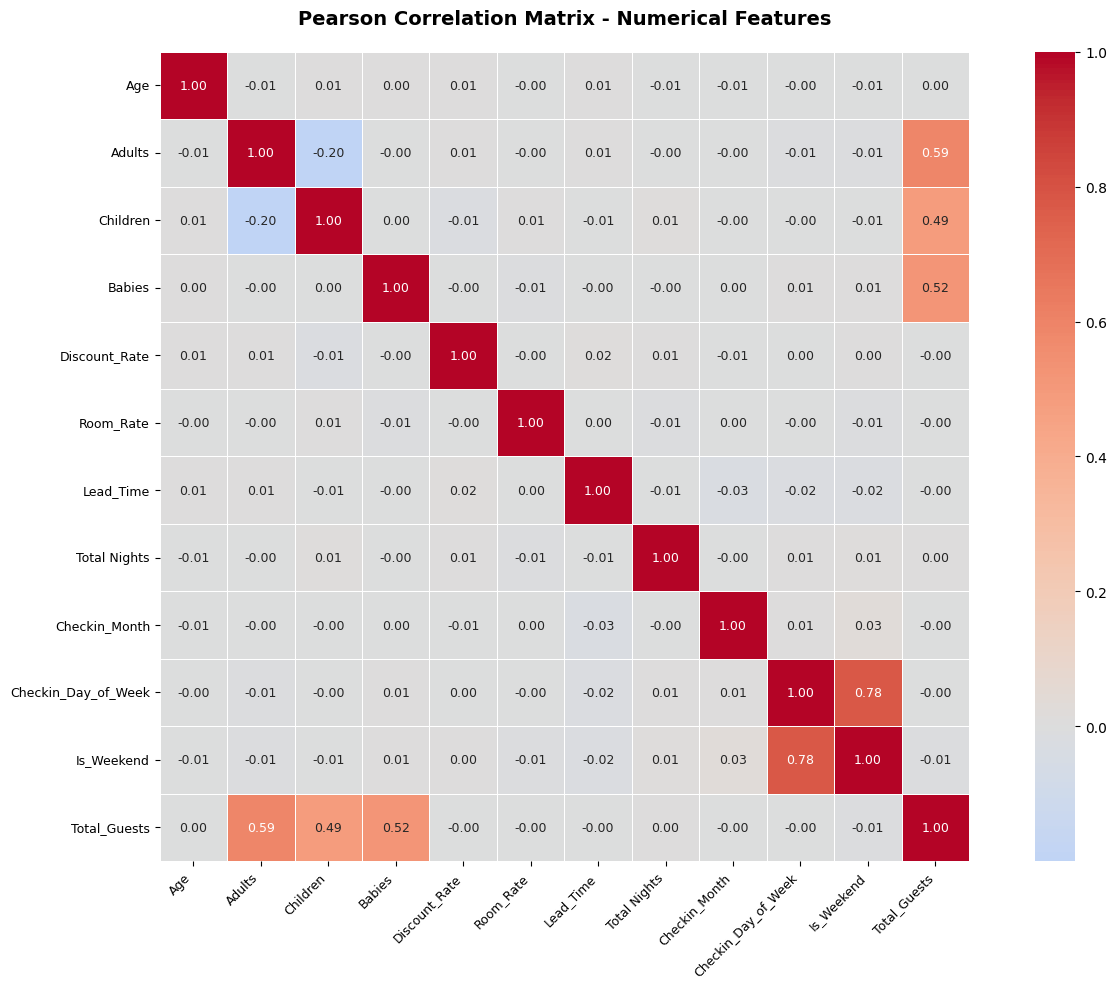

In [40]:

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure the folder exists
os.makedirs('images', exist_ok=True)

# List of numerical columns
numerical_columns = [
    'Age', 'Adults', 'Children', 'Babies',
    'Discount_Rate', 'Room_Rate', 'Lead_Time',
    'Total Nights', 'Checkin_Month', 'Checkin_Day_of_Week',
    'Is_Weekend', 'Total_Guests'
]

# Calculating the correlation matrix
corr_matrix = train_data_ML[numerical_columns].corr()

# Plotting the heatmap
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidth=0.5,
    annot_kws={"size": 9}
)

plt.title('Pearson Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# Save
save_path = '/content/drive/MyDrive/Data science project/correlation_heatmap.png'
plt.savefig(save_path, dpi=150)

print(f"Heatmap saved as '{save_path}'")

#####Multicollinearity occurs when independent variables are highly correlated, leading to redundant information and potentially leads to overfitting. In this dataset, a strong positive correlation between Is_Weekend and Checkin_Day_of_Week (r = 0.78) indicates redundancy, with the weekend indicator effectively capturing most of the temporal variation; therefore, Checkin_Day_of_Week was removed to reduce dimensionality. Similarly, Adults, Children, and Babies show moderate correlations with Total_Guests (r = 0.59, 0.49, 0.52), suggesting overlapping information; hence, only the aggregate feature Total_Guests was retained while the individual components were dropped.

###Chi-Square Analysis of Categorical Features Against the Target Variable to Detect Noise

In [36]:
#Chi squared test for categorical columns
from scipy.stats import chi2_contingency

cat_cols = [
    'Gender', 'Ethnicity', 'Educational_Level', 'Income',
    'Country_region', 'Hotel_Type', 'Meal_Type', 'Visted_Previously',
    'Previous_Cancellations', 'Deposit_type', 'Booking_channel',
    'Required_Car_Parking', 'Use_Promotion'
]

# Create a binary target variable 'is_canceled' from 'Reservation_Status'
# Assuming 'Canceled' or 'No-Show' indicates a cancellation, and 'Check-Out' does not.
train_data_ML['is_canceled'] = train_data_ML['Reservation_Status'].apply(lambda x: 1 if x in ['Canceled', 'No-Show'] else 0)

print("Chi-Square Test — Is this feature associated with cancellations?")
print("=" * 72)
print(f"{'Feature':<30} {'Chi2 Score':>12} {'P-Value':>12} {'Keep?':>10}")
print("-" * 72)

cols_to_drop_chi = []

for col in cat_cols:
    contingency_table = pd.crosstab(train_data_ML[col], train_data_ML['is_canceled'])
    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(contingency_table)

    #Decision
    if p_value < 0.05:
        decision = "YES(keep)"
    else:
        decision = "NO(drop)"
        cols_to_drop_chi.append(col)

    print(f"{col:<30} {chi2:>12.2f} {p_value:>12.6f} {decision:>10}")

print("-" * 72)
print(f"\nFeatures to consider dropping: {cols_to_drop_chi if cols_to_drop_chi else 'None — all categorical features are significant'}")

Chi-Square Test — Is this feature associated with cancellations?
Feature                          Chi2 Score      P-Value      Keep?
------------------------------------------------------------------------
Gender                                 0.07     0.793043   NO(drop)
Ethnicity                              1.41     0.702478   NO(drop)
Educational_Level                      0.73     0.865930   NO(drop)
Income                                 0.64     0.886698   NO(drop)
Country_region                         2.65     0.448771   NO(drop)
Hotel_Type                             0.95     0.623329   NO(drop)
Meal_Type                           1000.87     0.000000  YES(keep)
Visted_Previously                      1.21     0.270400   NO(drop)
Previous_Cancellations                 1.77     0.183567   NO(drop)
Deposit_type                           4.88     0.087021   NO(drop)
Booking_channel                        0.85     0.652502   NO(drop)
Required_Car_Parking                   0.38   

#####By applying the Chi-Square filter, categorical features that showed no meaningful trends in EDA- such as Required_Car_Parking and Use_Promotion were statistically confirmed as noise and removed. Conversely, features like Meal_Type and Hotel_Type, which displayed significant visual patterns during EDA, were validated by the test as statistically significant (p<0.05).

###ANOVA testing of Numerical Features Against the Target Variable to Detect Noise

In [34]:
# ANOVA test for numerical columns
from scipy.stats import f_oneway

# Split data into two groups based on cancellation
canceled     = train_data_ML[train_data_ML['is_canceled'] == 1]
not_canceled = train_data_ML[train_data_ML['is_canceled'] == 0]

print("ANOVA Test(Does this feature differ between cancellers and non-cancellers?)")
print("=" * 72)
print(f"{'Feature':<30} {'F-Statistic':>13} {'P-Value':>12} {'Keep?':>10}")
print("-" * 72)

cols_to_drop_anova = []

for col in numerical_columns:
    f_stat, p_value = f_oneway(
        canceled[col].dropna(),
        not_canceled[col].dropna()
    )

    if p_value < 0.05:
        decision = "YES(keep)"
    else:
        decision = "NO(drop)"
        cols_to_drop_anova.append(col)

    print(f"{col:<30} {f_stat:>13.2f} {p_value:>12.6f} {decision:>10}")

print("-" * 72)
print(f"\nFeatures to consider dropping: {cols_to_drop_anova if cols_to_drop_anova else 'None — all numerical features are significant'}")

ANOVA Test(Does this feature differ between cancellers and non-cancellers?)
Feature                          F-Statistic      P-Value      Keep?
------------------------------------------------------------------------
Age                                     0.03     0.869227   NO(drop)
Adults                                  0.01     0.942961   NO(drop)
Children                                2.65     0.103642   NO(drop)
Babies                                  0.00     0.971679   NO(drop)
Discount_Rate                           0.00     0.977765   NO(drop)
Room_Rate                               0.00     0.943980   NO(drop)
Lead_Time                               4.71     0.029942  YES(keep)
Total Nights                            0.20     0.658075   NO(drop)
Checkin_Month                           9.91     0.001644  YES(keep)
Checkin_Day_of_Week                    75.35     0.000000  YES(keep)
Is_Weekend                             65.12     0.000000  YES(keep)
Total_Guests           

By combining careful statistical analysis with practical business sense, we removed 6 variables that didn’t add value: Adults, Children, Babies, Previous_Cancellations, Is_Repeated_Guest, and Discount_Rate. At the same time, we kept a strong set of predictors, such as Age, Room_Rate, and Total_Nights, which truly matter from a business perspective, even if they are statistically less significant. This approach ensures the model isn’t just a “black box” of numbers, but a practical tool that makes sense and reflects how real hotels operate.

#####